# Time-Resolved CIDNP Simulation; Triplet-Born Radical Pair; Recombination product
## Haberkorn and Lindblad Dynamics 
### Author: Marta Stefańska (University of Basel, Biozentrum; email: marta.stefanska@unibas.ch)

In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib ipympl

# Import PyOR package
from PyORv2 import *

*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QunS                   (QuantumSystem from PyOR_QuantumSystem)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting              (from PyOR_Plotting)
** Spro                  (from PyOR_SignalProcessing)
** constants             (from PyOR_PhysicalConstants)
** gamma                 (from PyOR_Gamma)
* QunObj                 (from PyOR_QuantumObject)
* QuantumLibrary      

### Parameters 
Hyperfine interactions and g factors calculated in Orca 5.0 for system paracetamol - fluorescein. The rates choosen arbitrary. Both nuclei belong to paracetamol molecule.

In [2]:
A1_iso_Hz = 3.29e6       # Hz  
A2_iso_Hz = -14.42e6     # Hz
g1, g2 = 2.003234, 2.00340264  
J_coupling_Hz = 8.8      # Hz 
J_ex_Hz = 0.5            # Hz 
B0_field = 14.1           # T
k_S = 1.0e7              # s^-1
k_T = 5.0e5              # s^-1
t_CIDNP = 0.03e-6        # s  
muB = constants("bm") / constants("pl")  # Hz/T
n_points = 5000
gamma_H = gamma("H1")

def electron_offset(g_actual, B0):
    g_free = 2.002319304
    muB_local = constants("bm") / constants("pl")
    return muB_local * B0 * (g_actual - g_free)  # Hz

### SCRP - Spin-Correlated Radical Pair Setup
Two electrons, one on photosensitizer (fluorescein), second on the target molecule (paracetamol).

In [3]:
QS = QunS({"S1": "E", "S2": "E", "I1": "H1", "I2": "H1"}, PrintDefault=False)

QS.Configure(
    PropagationSpace="Hilbert",
    MasterEquation="Lindblad",
    B0=B0_field,
    OFFSET={
        "S1": electron_offset(g1, B0_field),
        "S2": electron_offset(g2, B0_field),
        "I1": 50,
        "I2": -50,
    },
    Rprocess="user Defined Dissipator",
    Jcouplings=[("I1", "I2", J_coupling_Hz)],

    # Evolution
    AcqDT = t_CIDNP / n_points,
    AcqAQ = t_CIDNP,
    OdeMethod = 'DOP853',
    PropagationMethod = "ODE Solver Lindblad",
)

I_full = QS.Eye(QS.Vdim)

Spin Operators generated (Quantum Objects)
For particle S1: S1x, S1y, S1z, S1p, S1m
For particle S2: S2x, S2y, S2z, S2p, S2m
For particle I1: I1x, I1y, I1z, I1p, I1m
For particle I2: I2x, I2y, I2z, I2p, I2m

To see the matrix form use the attribute .matrix
Spin Operators generated (Quantum Objects)
For particle S1: S1x, S1y, S1z, S1p, S1m
For particle S2: S2x, S2y, S2z, S2p, S2m
For particle I1: I1x, I1y, I1z, I1p, I1m
For particle I2: I2x, I2y, I2z, I2p, I2m

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2482812177000.0, -2482812177000.0, -3772062004.7999997, -3772062004.7999997] from {'S1': -2482812177000.0, 'S2': -2482812177000.0, 'I1': -3772062004.7999997, 'I2': -3772062004.7999997}
Offset    <- OFFSET    : [180514471.39436123, 213795430.81251696, 50, -50] from {'S1': 180514471.39436123, 'S2': 213795430.81251696, 'I1': 50, 'I2': -50}
Ispintemp <- I_spintemp: [300,

### Hamiltonian for RP evolution

In [4]:
Hz = QS.Hamiltonian.Zeeman_RotFrame()

### Hyperfine Hamiltonian
$$
H_{hf} = A_1 \mathbf{S}_2 \cdot \mathbf{I}_1 + A_2 \mathbf{S}_2 \cdot \mathbf{I}_2
$$

In [5]:
A1_omega = 2.0 * QS.pi * A1_iso_Hz  # rad/s
A2_omega = 2.0 * QS.pi * A2_iso_Hz  # rad/s

H_hf1 = A1_omega * (QS.S2x * QS.I1x + QS.S2y * QS.I1y + QS.S2z * QS.I1z)
H_hf2 = A2_omega * (QS.S2x * QS.I2x + QS.S2y * QS.I2y + QS.S2z * QS.I2z)

#### Electron-electron scalar product

In [6]:
S1_dot_S2 = QS.S1x * QS.S2x + QS.S1y * QS.S2y + QS.S1z * QS.S2z

#### Exchange Hamiltonian
$$
H_{\mathrm{ex}} = -2J\, \mathbf{S}_1 \cdot \mathbf{S}_2
$$

In [7]:
H_ex = -2.0 * 2.0 * QS.pi * J_ex_Hz * S1_dot_S2 # rad/s

### Full radical pair evolution Hamiltonian
$$
H = \omega_1 S_{1z} + \omega_2 S_{2z} + 2\pi J_{12}\, \mathbf{I}_1 \cdot \mathbf{I}_2
+ A_1\, \mathbf{S}_2 \cdot \mathbf{I}_1 + A_2\, \mathbf{S}_2 \cdot \mathbf{I}_2
- 2J_{\mathrm{ex}}\, \mathbf{S}_1 \cdot \mathbf{S}_2
$$

a. McLauchlan, K. A.; Steiner, U. E. The spin-correlated radical pair as a reaction intermediate. Mol. Phys. 1991, 73, 241–263. https://doi.org/10.1080/00268979100101181

b. Steiner, U. E.; Ulrich, T. Magnetic field effects in chemical kinetics and related phenomena. Chem. Rev. 1989, 89, 51–147. https://doi.org/10.1021/cr00091a003

In [8]:
H_RP = H_hf1 + H_hf2 + Hz + H_ex

### Projector operators
$$
P_S = \frac{1}{4}\mathbf{1} - \mathbf{S}_1 \cdot \mathbf{S}_2, \quad
P_T = 1 - P_S = \frac{3}{4}\mathbf{1} + \mathbf{S}_1 \cdot \mathbf{S}_2
$$


In [9]:
P_S = 0.25 * I_full - S1_dot_S2
P_T = I_full - P_S

### Initial state, triplet-born SCRP

In [10]:
P_Tp = (0.5 * I_full + QS.S1z) * (0.5 * I_full + QS.S2z)
P_Tm = (0.5 * I_full - QS.S1z) * (0.5 * I_full - QS.S2z)
P_T0 = P_T - P_Tp - P_Tm
rho_init = P_T0 / P_T0.Trace()

### RP Evolution
#### 1. Haberkorn
$$
\left(\frac{d\rho}{dt}\right)_{\mathrm{rctn}} = -\frac{K_1}{2}\left(P\rho + \rho P\right)
$$


#### 2. Lindblad
$$
\left(\frac{d\rho}{dt}\right)_{\mathrm{rctn}} = K_2\, P \rho P - \frac{K_1}{2}\left(P\rho + \rho P\right)
$$

a. Haberkorn, R. Density matrix description of spin-selective radical pair reactions. Mol. Phys. 1976, 32, 1491–1493. https://doi.org/10.1080/00268977600102851

b. Ivanov, K. L.; Petrova, M. V.; Lukzen, N. N.; Maeda, K. Consistent treatment of spin-selective recombination of a radical pair confirms the Haberkorn approach. J. Phys. Chem. A 2010, 114, 9447–9455. https://doi.org/10.1021/jp1048265

c. Jones, J. A.; Hore, P. J. Spin-selective reactions of radical pairs act as quantum measurements. Chem. Phys. Lett. 2010, 488 (1–3), 90–93. https://doi.org/10.1016/j.cplett.2010.01.063

In [11]:
# Define Lindblad Dissipator

QS.Configure(
    uDissipator = [(k_S, P_S, P_S), (k_T, P_T, P_T)],
    uDissipator_only_anticomm = True  # Select Haberkorn (True) or Lindblad (False)
)

start_time = time.time()
t, rho_t = QS.Evolutions.Evolution(rho_init, rho_init, H_RP)
end_time = time.time()

Spin Operators generated (Quantum Objects)
For particle S1: S1x, S1y, S1z, S1p, S1m
For particle S2: S2x, S2y, S2z, S2p, S2m
For particle I1: I1x, I1y, I1z, I1p, I1m
For particle I2: I2x, I2y, I2z, I2p, I2m

To see the matrix form use the attribute .matrix

Setting derived parameters from dictionaries
-------------------------------------------
OmegaRF   <- OMEGA_RF  : [-2482812177000.0, -2482812177000.0, -3772062004.7999997, -3772062004.7999997] from {'S1': -2482812177000.0, 'S2': -2482812177000.0, 'I1': -3772062004.7999997, 'I2': -3772062004.7999997}
Offset    <- OFFSET    : [180514471.39436123, 213795430.81251696, 50, -50] from {'S1': 180514471.39436123, 'S2': 213795430.81251696, 'I1': 50, 'I2': -50}
Ispintemp <- I_spintemp: [300, 300, 300, 300] from {'S1': 300, 'S2': 300, 'I1': 300, 'I2': 300}
Fspintemp <- F_spintemp: [300, 300, 300, 300] from {'S1': 300, 'S2': 300, 'I1': 300, 'I2': 300}
RDxi      <- RD_xi     : [0, 0, 0, 0] from {'S1': 0, 'S2': 0, 'I1': 0, 'I2': 0}
RDphase   <- RD

In [12]:
QS.uDissipator

[(10000000.0,
  <PyORv2.PyOR_QuantumObject.QunObj at 0x721b047e5fd0>),
 (500000.0,
  <PyORv2.PyOR_QuantumObject.QunObj at 0x721b047e6000>)]

In [13]:
rho_t = [(r + r.conj().T) / 2 for r in rho_t]  # enforce Hermitian

rho_prod = QS.Zeros((4, 4),QuantumObject=False)

I1z_n = QS.I1z_sub.TensorProduct(QS.Eye(2))
I2z_n = QS.Eye(2).TensorProduct(QS.I2z_sub)
I1zI2z_n = I1z_n * I2z_n

I1z_prod, I2z_prod, I1zI2z_prod = [], [], []

for i, rho in enumerate(rho_t):
    rho_S = QS.Evolutions.PartialTrace(k_S * P_S.data @ rho @ P_S.data * QS.AcqDT, keep=[2, 3])
    rho_T = QS.Evolutions.PartialTrace(k_T * P_T.data @ rho @ P_T.data * QS.AcqDT, keep=[2, 3])
    rho_prod = rho_prod + rho_S + rho_T

    I1z_prod.append(QS.Trace(rho_prod @ I1z_n.data).real)
    I2z_prod.append(QS.Trace(rho_prod @ I2z_n.data).real)
    I1zI2z_prod.append(QS.Trace(rho_prod @ I1zI2z_n.data).real)

_, trace = QS.Evolutions.Expectation(rho_t, QS.Eye(QS.Vdim))
_, pop_S = QS.Evolutions.Expectation(rho_t, P_S)
_, pop_T = QS.Evolutions.Expectation(rho_t, P_T)

In [14]:
print(f"\nFinal trace: {QS.Trace(rho_t[-1]).real:.6f}")
print(f"Product trace: {QS.Trace(rho_prod).real:.6f}")
print(f"\nFinal I1z : {I1z_prod[-1]:.4e}")
print(f"Final I2z : {I2z_prod[-1]:.4e}")
print(f"Final P12 : {I1zI2z_prod[-1]:.4e}")


Final trace: 0.850835
Product trace: 0.149178

Final I1z : 8.2232e-04
Final I2z : -9.3372e-03
Final P12 : -3.3510e-04


In [15]:
QS.Plotting.PlotFigureSize = (10, 5)
QS.Plotting.PlotFontSize = 20

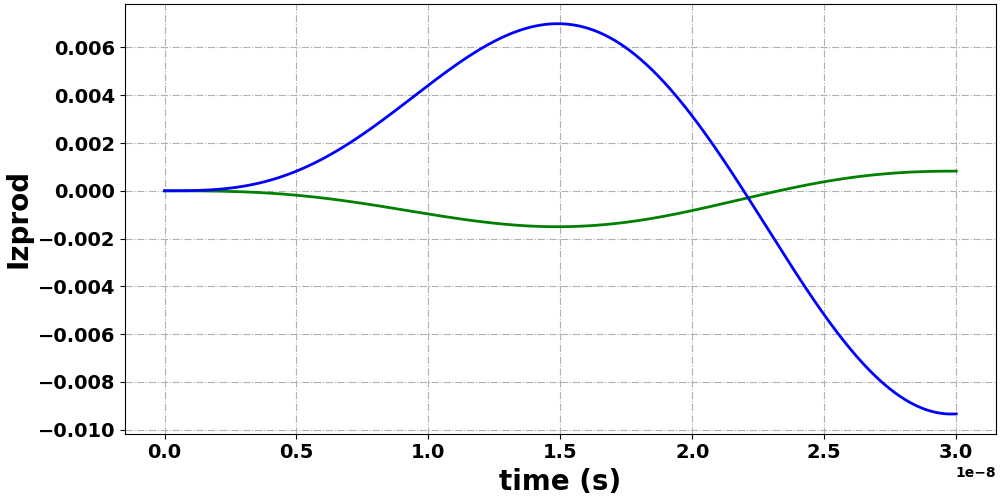

In [16]:
# Plot I1z and I2z product polarizations
QS.Plotting.PlottingMulti([t, t], [I1z_prod, I2z_prod],
                   "time (s)", "Izprod", ["green", "blue"])

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x721b00c1e900>)

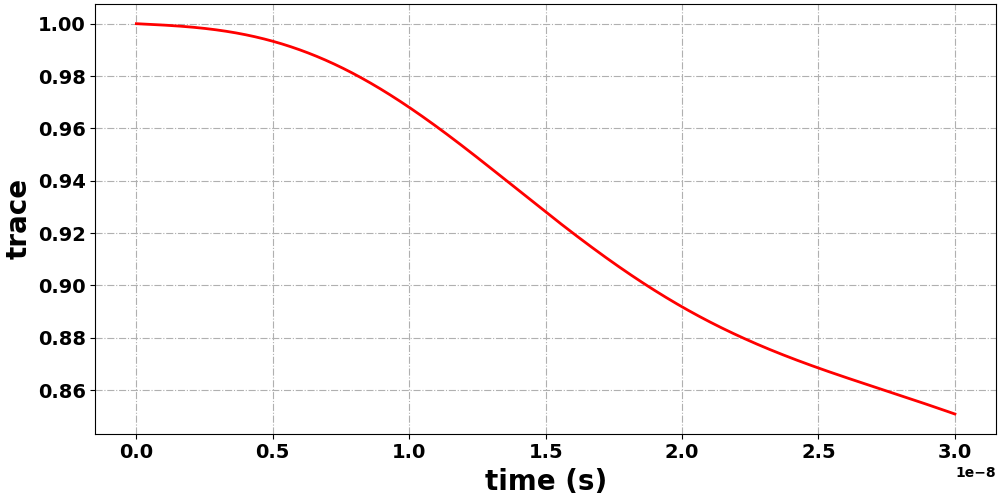

In [17]:
# Plot trace decay
trace = QS.Array(trace).real
pop_S = QS.Array(pop_S).real
pop_T = QS.Array(pop_T).real
QS.Plotting.Plotting_SpanSelector(t, trace, "time (s)", "trace", "red")

(<Figure size 1000x500 with 1 Axes>,
 <matplotlib.widgets.SpanSelector at 0x721b00c40d40>)

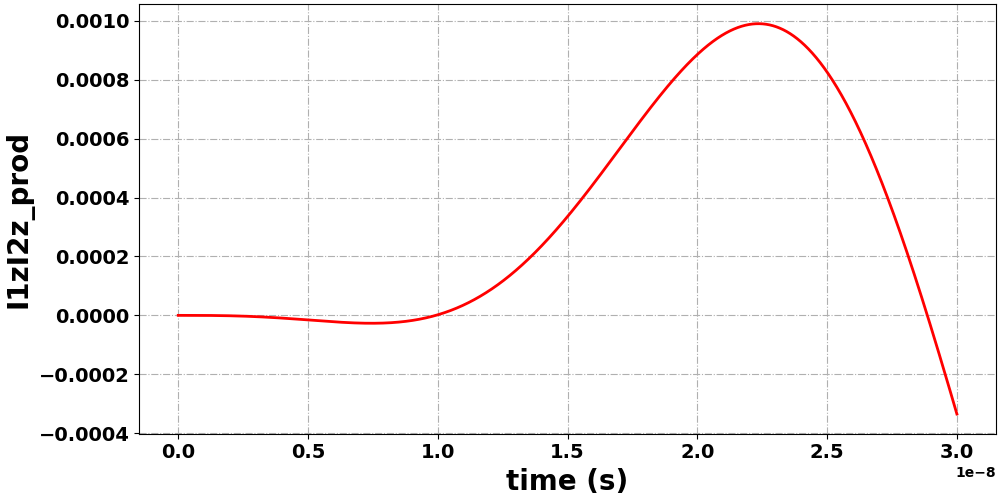

In [18]:
# Plot two-spin order
QS.Plotting.Plotting_SpanSelector(t, I1zI2z_prod, "time (s)", "I1zI2z_prod", "red")

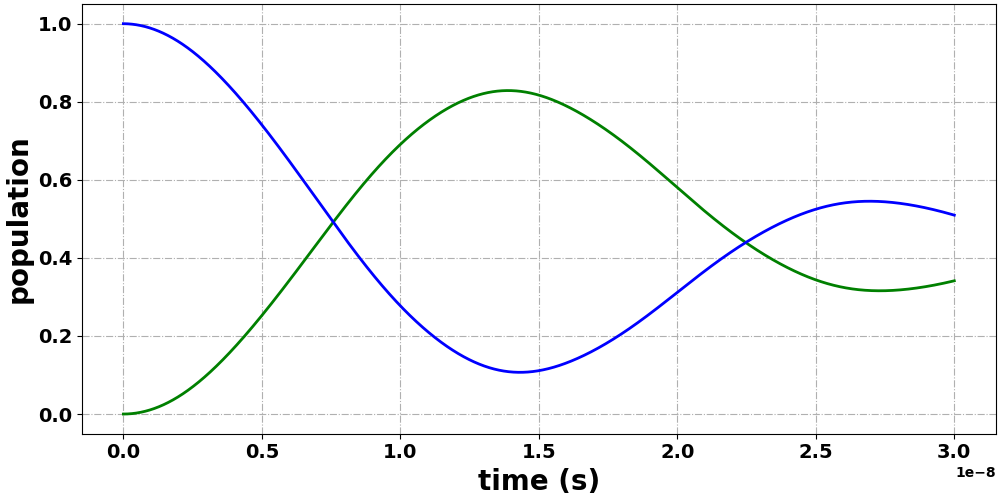

In [19]:
# Plot singlet and triplet populations
QS.Plotting.PlottingMulti([t, t], [pop_S, pop_T],
                   "time (s)", "population", ["green", "blue"])